In [66]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve

from copy import deepcopy
from jax.lax import slice as jax_slice
from jax.scipy.signal import convolve2d

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

In [ ]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val


def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')

In [32]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


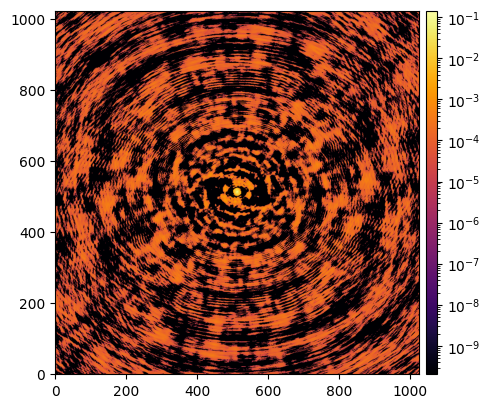

In [33]:
space_512 = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space_512)

kernel_512 = compute_psf_kernel(RNR_l)

plot_arrays(kernel_512, norm='log', dpi=100)

In [152]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')



exp_it = 3
sky_it = optim_cfg.instantiate_sec(f'sky.{exp_it}')

skies_c, means_c = [], []
with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    smp_c, *_ = pickle.load(f)
for sky_c in sky_it.signals + sky_it.points:
    print(sky_c.prefix)
    mean = smp_c.mean(sky_c)
    skies_c += [sky_c, ]
    means_c += [map_signal(mean, sky_c.space, skies_c[0].space), ]

signal_bg, space_bg = downsample(means_c[0], 2), skies_c[0].space * 0.5
signal_t0, space_t0 = downsample(means_c[1], 2), skies_c[1].space * 0.5
signal_t1, space_t1 = downsample(means_c[2], 2), skies_c[2].space * 0.5
signal_t2, space_t2 = downsample(means_c[3], 2), skies_c[3].space * 0.5
# signal_ps, space_ps = smp_c.mean(sky_it.points[0].points), skies_c[4].space
signal_sum = signal_bg + signal_t0 + signal_t1 + signal_t2

bg.3
o0.3
o1.3
o2.3
p0.3


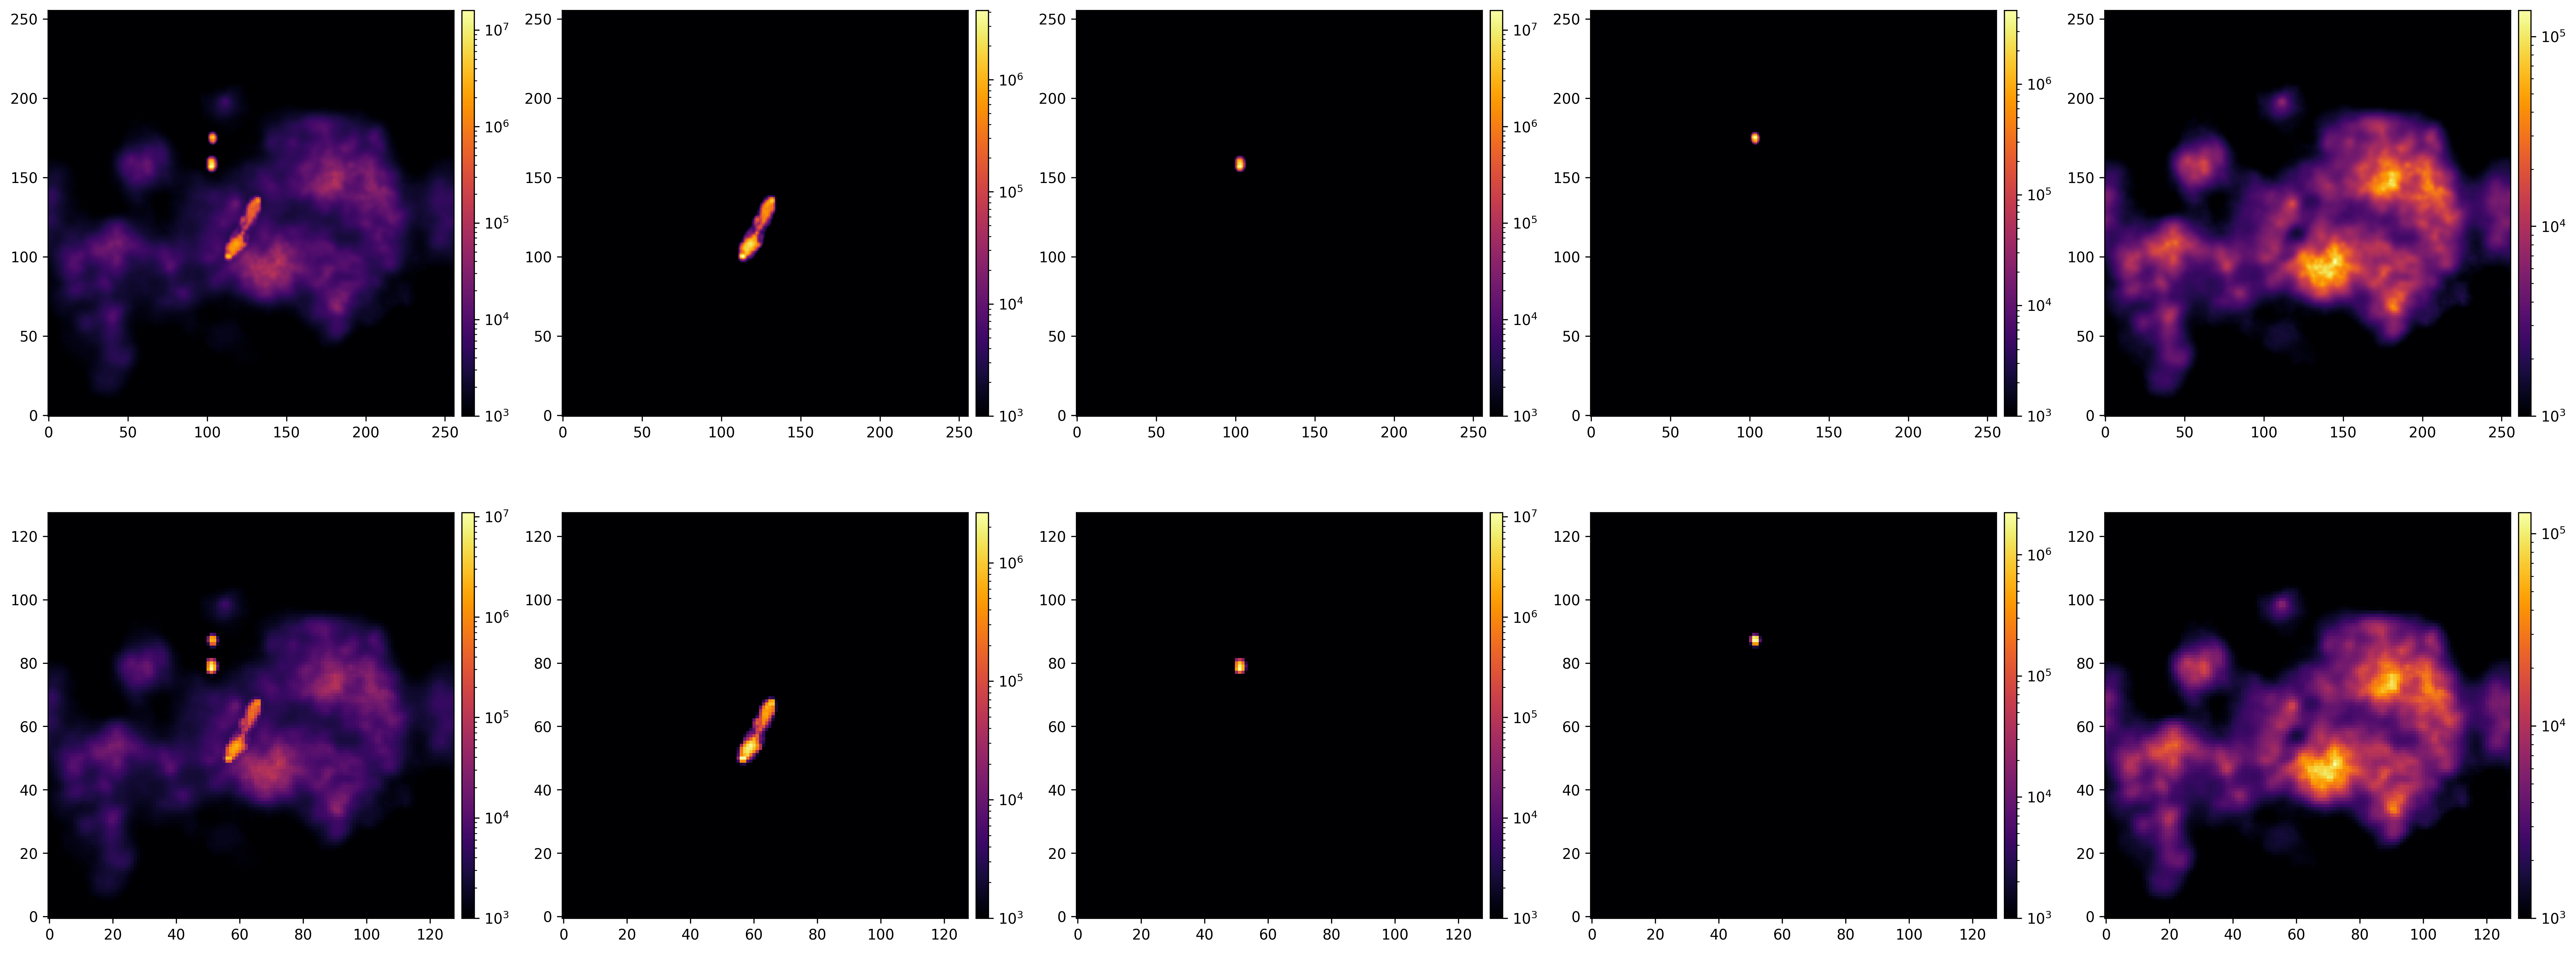

In [153]:
zoom = 2

signal_dict = {
    'sum': {'val': signal_sum, 'low': downsample(signal_sum, zoom), 'spc': space_bg},
    't0': {'val': signal_t0, 'low': downsample(signal_t0, zoom), 'spc': space_t0.transform(shape=(40, 56))},
    't1': {'val': signal_t1, 'low': downsample(signal_t1, zoom), 'spc': space_t1.transform(shape=(16, 20))},
    't2': {'val': signal_t2, 'low': downsample(signal_t2, zoom), 'spc': space_t2},
    # 'ps': {'val': means_c[3], 'low': downsample(means_c[3], zoom), 'spc': skies_c[3].points.space},
    'bg': {'val': signal_bg, 'low': downsample(signal_bg, zoom), 'spc': space_bg},
    'fac': zoom,
}

kernel = downsample(kernel_512, zoom)

plot_arrays([sig['val'] for sig in signal_dict.values() if isinstance(sig, dict)] + [sig['low'] for sig in signal_dict.values() if isinstance(sig, dict)], norm='log', dpi=300, rows=2, vmin=1e3)

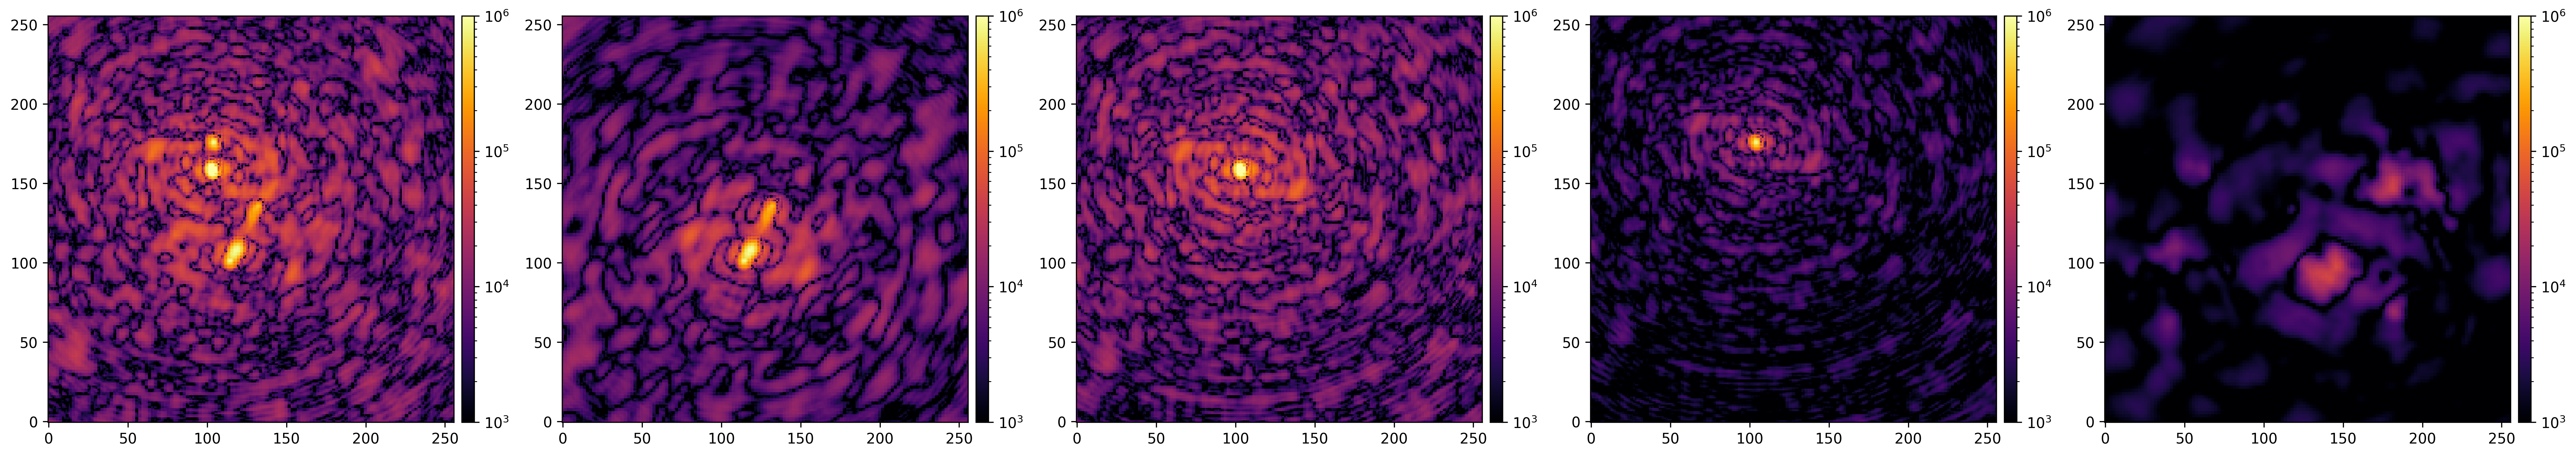

In [166]:
rsp_err = []
low_res_err = np.zeros_like(signal_dict['sum']['val'])
ker_low = downsample(kernel, zoom)
for k,sig in signal_dict.items():
    if isinstance(sig, dict):
        rsp_low = convolve2d(sig['low'], ker_low, mode='same') * zoom
        rsp_low = upsample(rsp_low, zoom)
        rsp_val = convolve2d(sig['val'], kernel, mode='same')
        rsp_err += [rsp_val - rsp_low, ]
        if k != 'sum':
            low_res_err += (rsp_val - rsp_low) * (1 - map_signal(np.ones(sig['spc'].shape), sig['spc'], signal_dict['sum']['spc'], order=1))

plot_arrays([np.abs(err) for err in rsp_err], dpi=300, rows=1, norm='log', vmin=1e3, vmax=1e6)

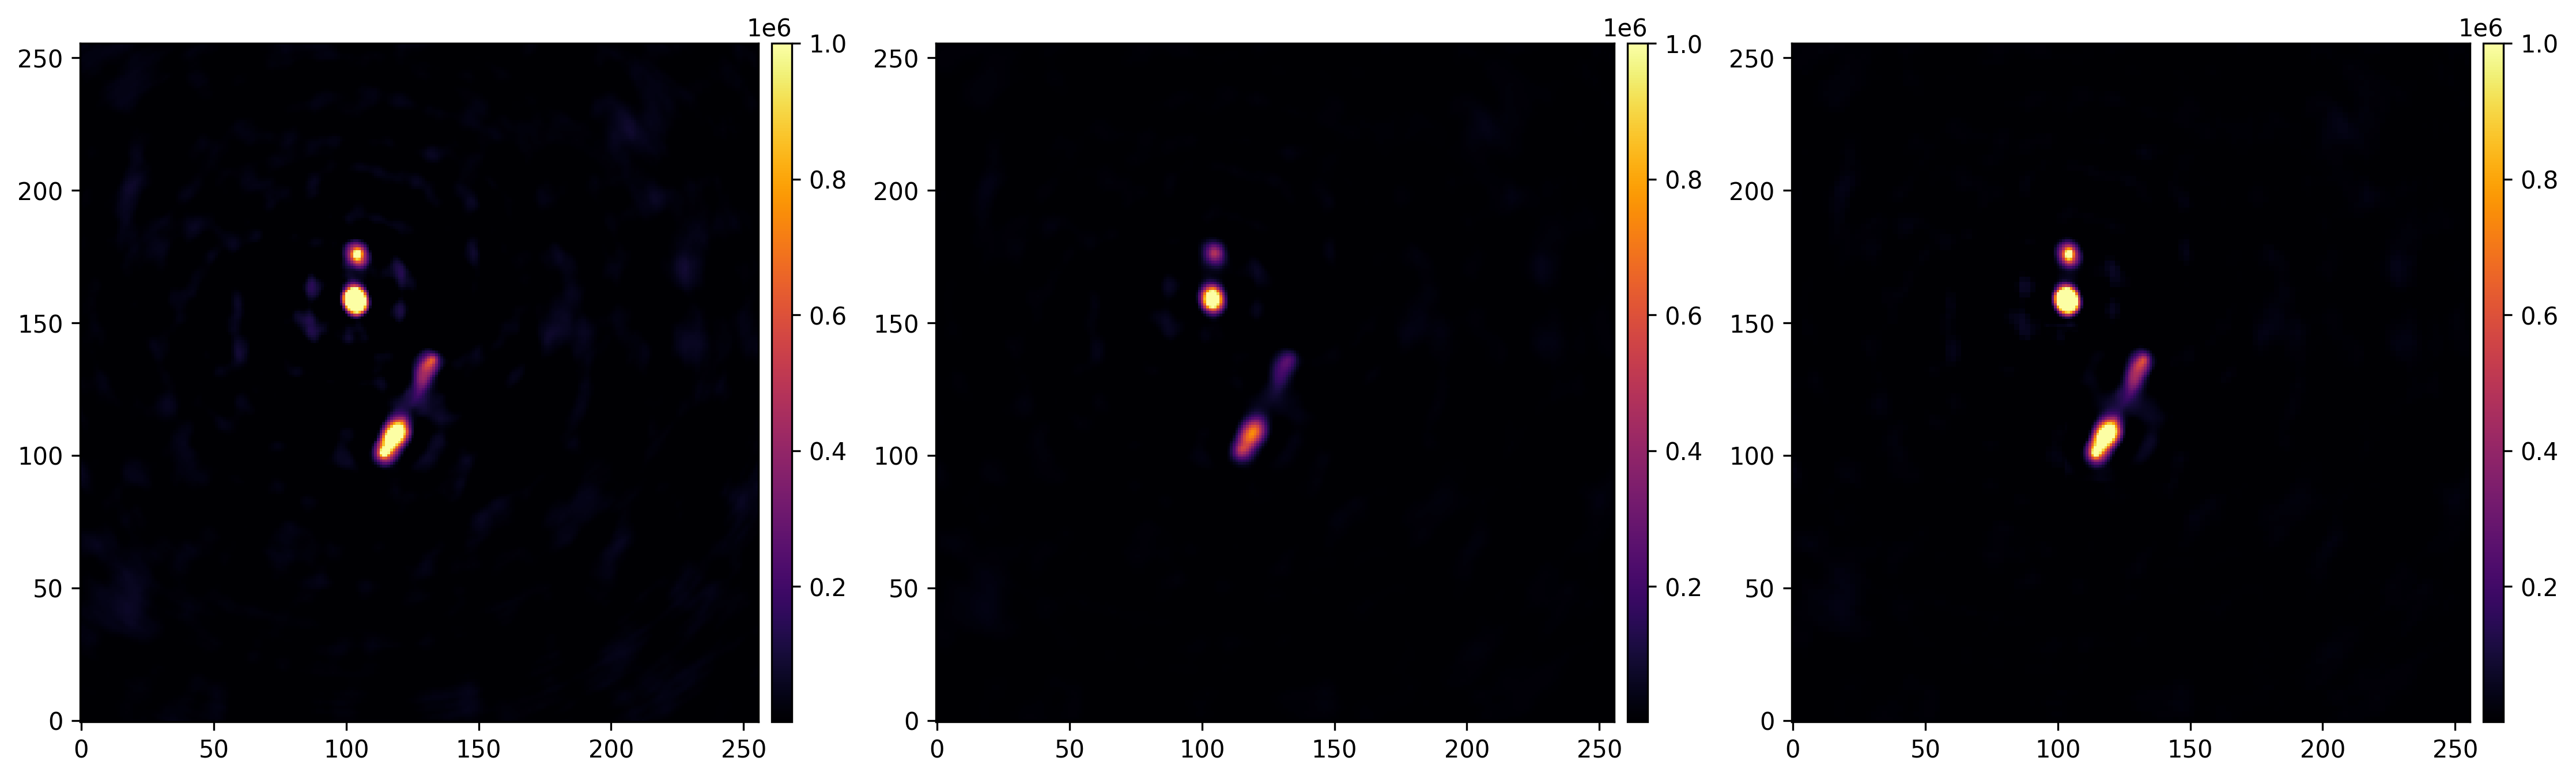

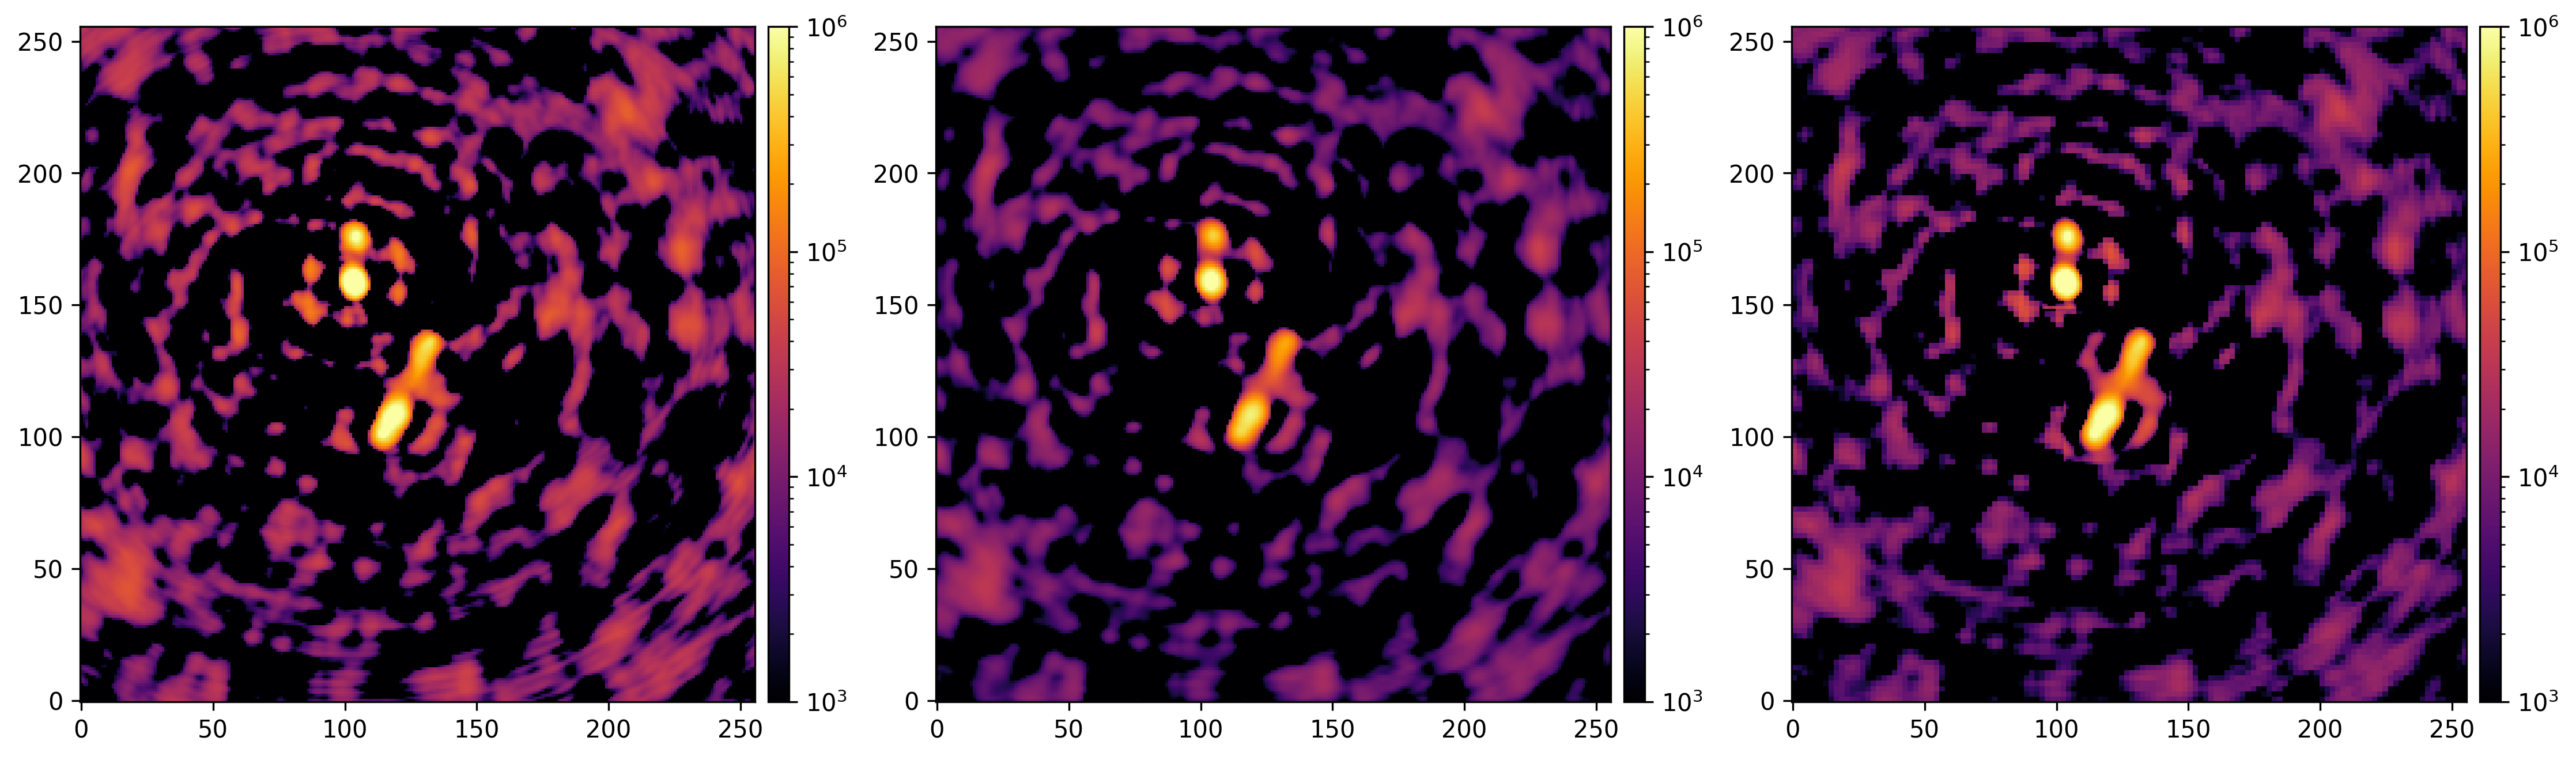

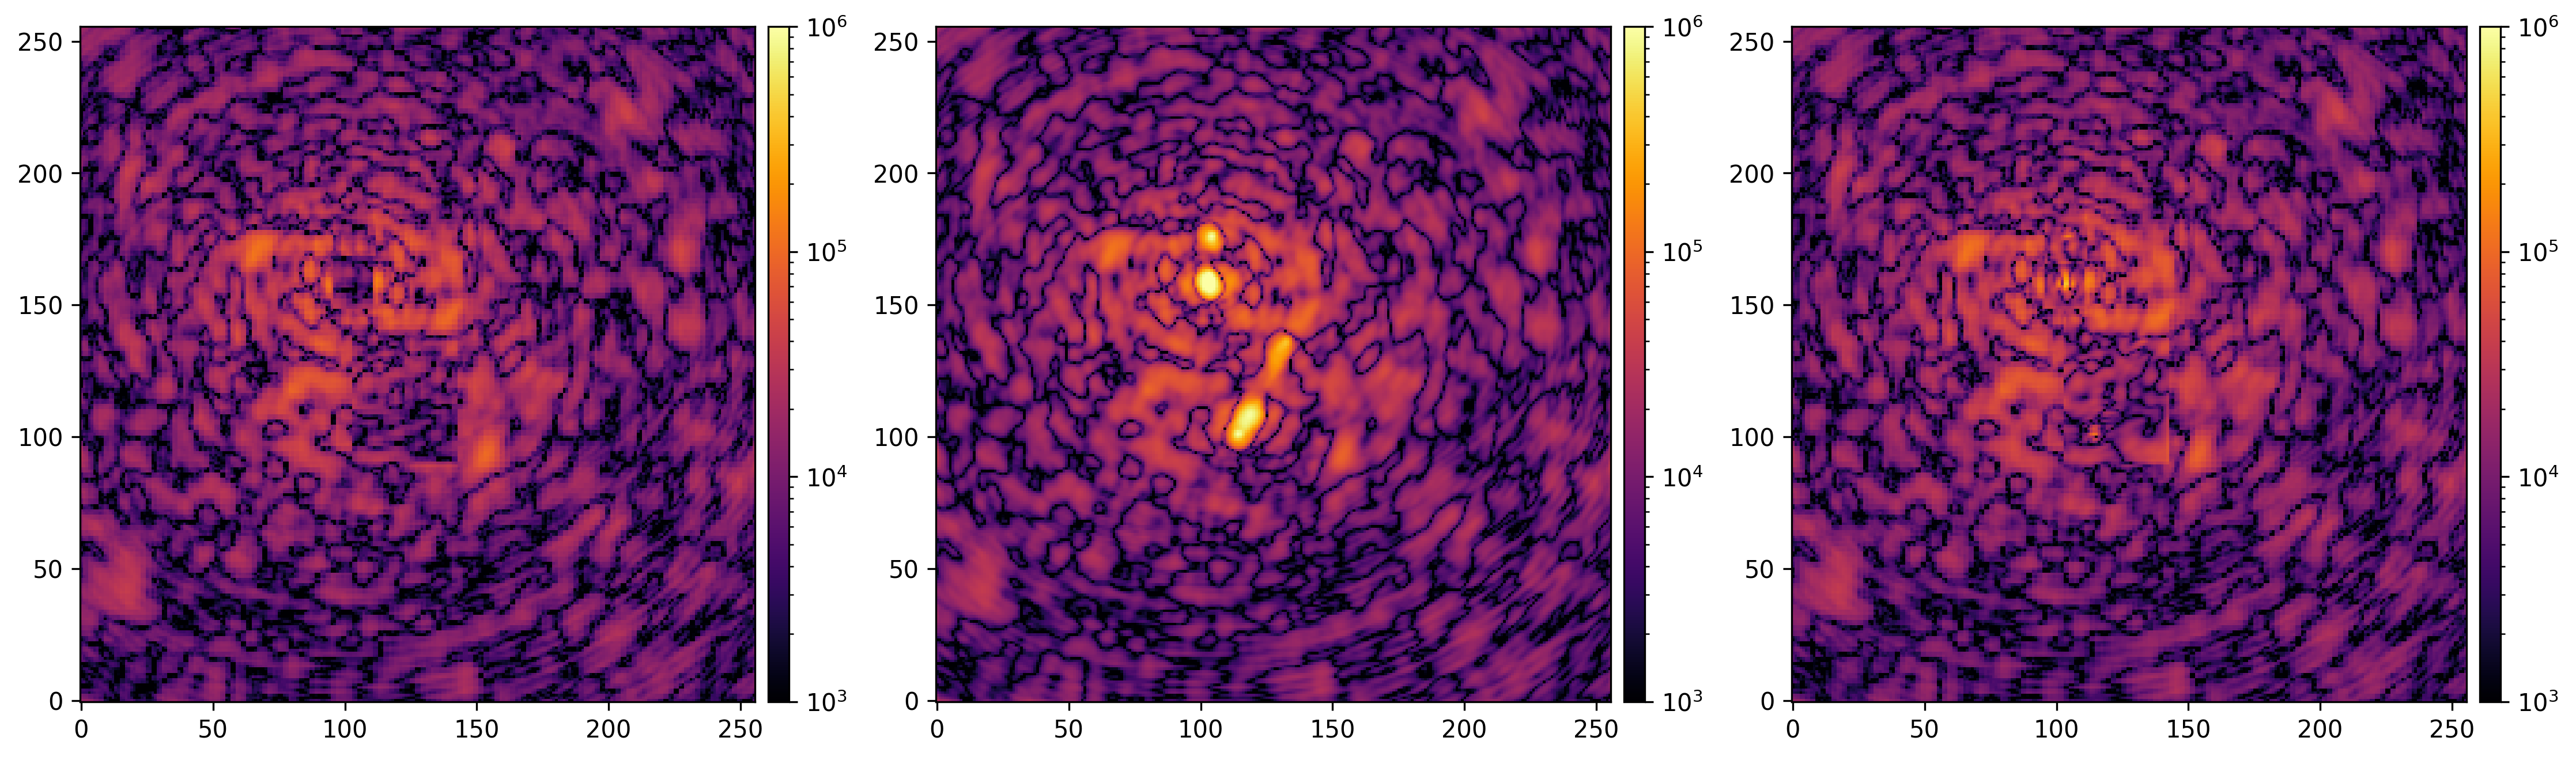

In [185]:
def multi_scale_kernel(signal_dict, kernel, order=1):
    signal_dict = deepcopy(signal_dict)
    fac = signal_dict['fac']
    space = signal_dict['sum']['spc']
    space_low = space * (1/fac)

    # kernel_low = downsample(kernel, fac)
    kernel_low = map_signal(kernel, 2*space, (2/fac)*space, order)
    response_low = convolve2d(signal_dict['sum']['low'], kernel_low, mode='same') * fac
    response_val = upsample(response_low, fac)

    for key, sig in filter(lambda x: 't' in x[0], signal_dict.items()):
        sig_high = map_signal(sig['val'], space, sig['spc'], order)
        ker_high = map_signal(kernel, 2*space, 2*sig['spc'].transform(center=None), order)
        rsp_high = convolve2d(sig_high, ker_high, mode='same')

        sig_low = map_signal(sig['low'], space_low, sig['spc']*(1/fac), order)
        # ker_low = downsample(ker_high, fac)
        ker_low = map_signal(ker_high, 2*sig['spc'].transform(center=None), (2/fac)*sig['spc'].transform(center=None), order)
        rsp_low = convolve2d(sig_low, ker_low, mode='same') * fac

        rsp_slc = map_signal(response_low, space_low, sig['spc']*(1/fac), order)
        rsp_sub = rsp_slc - rsp_low
        # rsp_add = upsample(rsp_sub, fac) + rsp_high
        rsp_add = map_signal(rsp_sub, sig['spc']*(1/fac), sig['spc'], order) + rsp_high
        rsp_val = map_signal(rsp_add, sig['spc'], space, order)

        msk_val = map_signal(np.ones(sig_high.shape), sig['spc'], space, order)
        response_val = response_val * (1 - msk_val).clip(0, 1) + rsp_val

    # for key, sig in filter(lambda x: 'ps' in x[0], signal_dict.items()):
    #     slc = slice(sig['idx'] - sig['ker_pix']//2, sig['idx'] + sig['ker_pix']//2)
    #     slc_low = slice(slc.start//fac, slc.stop//fac)

    #     ker_high = kernel[kernel.size//2 - sig['ker_pix']//2 : kernel.size//2 + sig['ker_pix']//2]
    #     rsp_val = ker_high * sig['val'][sig['idx']]

    #     ker_low = downsample(ker_high, fac)
    #     rsp_low = ker_low * sig['low'][sig['idx']//fac] * fac

    #     rsp_slc = response_low[slc_low]
    #     rsp_sub = rsp_slc - rsp_low
    #     rsp_add = upsample(rsp_sub, fac) + rsp_val
    #     response_val[slc] = rsp_add

    return response_val


response_high = convolve2d(signal_dict['sum']['val'], kernel, mode='same')
response_low = convolve2d(signal_dict['sum']['low'], downsample(kernel, signal_dict['fac']), mode='same') * signal_dict['fac']
# response_low = upsample(response_low, signal_dict['fac'])
response_low = map_signal(response_low, signal_dict['sum']['spc']*(1/signal_dict['fac']), signal_dict['sum']['spc'], order=1)


response_ms = multi_scale_kernel(signal_dict, kernel)

plot_arrays([response_high, response_low, response_ms], dpi=300, rows=1, vmin=1e3, vmax=1e6)
plot_arrays([response_high, response_low, response_ms], dpi=300, rows=1, norm='log', vmin=1e3, vmax=1e6)

response_errors = [low_res_err, response_high - response_low, response_high - response_ms]

plot_arrays([np.abs(err) for err in response_errors], dpi=300, rows=1, norm='log', vmin=1e3, vmax=1e6)